# Análisis de Expresión Diferencial con PyDESeq2 y Preparación de Features para Machine Learning

* **Autor:** Sebastián Toro & Gemini
* **Fecha:** 2026-05-08
* **Propósito:** Este notebook guía a través de un flujo de trabajo completo para el análisis de expresión diferencial utilizando PyDESeq2 en Python. Se aborda desde el preprocesamiento de datos de conteos (FeatureCounts) y metadatos, la ejecución de la inferencia estadística, la visualización de resultados (PCA, Volcano Plot), hasta la exportación de una matriz de features lista para modelos de Machine Learning.

**Objetivos de Aprendizaje:**
*   Cargar y preprocesar datos de conteos de FeatureCounts y metadatos para PyDESeq2.
*   Ejecutar el pipeline de normalización, estimación de dispersión y cálculo de estadísticos de expresión diferencial con PyDESeq2.
*   Realizar la Transformación Estabilizadora de Varianza (VST) para análisis exploratorios.
*   Generar un Plot de Componentes Principales (PCA) para visualizar la separación de muestras.
*   Crear un Volcano Plot para identificar genes diferencialmente expresados.
*   Preparar una "Master Table" con features VST y un label objetivo numérico para Machine Learning.

---

## 1. Introducción

El análisis de expresión diferencial (DEA, por sus siglas en inglés) es un pilar fundamental en la transcriptómica de RNA-seq, permitiendo identificar genes con cambios significativos en su expresión entre diferentes condiciones experimentales. DESeq2, originalmente un paquete de R, es una de las herramientas más robustas y ampliamente utilizadas para esta tarea.

**PyDESeq2** es una implementación en Python de DESeq2, que busca replicar su funcionalidad principal y ofrecer una alternativa para usuarios de Python. Este notebook te guiará a través de un flujo de trabajo típico de DEA usando PyDESeq2, integrando pasos de preprocesamiento y post-procesamiento que son comunes en la bioinformática.

### Flujo de Trabajo del Notebook:

1.  **Carga y Preprocesamiento de Metadatos:** Preparación del archivo `.csv` con la información de las muestras.
2.  **Carga y Preprocesamiento de Conteos:** Adaptación de la matriz de conteos generada por FeatureCounts.
3.  **Inferencia Estadística con PyDESeq2:** Ejecución del modelo DESeq2 para identificar genes diferencialmente expresados.
4.  **Transformación VST y Visualización PCA:** Normalización para visualización y análisis exploratorio de la varianza.
5.  **Visualización Volcano Plot:** Identificación gráfica de genes significativos.
6.  **Exportación de Master Table para Machine Learning:** Preparación de una matriz de features para modelos predictivos.

---

## 2. Configuración de Librerías y Carga de Datos

In [2]:
# Las siguientes librerías se asumen ya instaladas en su entorno Conda.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb 

# PyDESeq2 y Machine Learning
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from sklearn.decomposition import PCA

print("Librerías cargadas exitosamente.")

# Configuración de gráficos global
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
sb.set_theme(style="whitegrid") # Usamos sb en lugar de sns
print("Configuración de gráficos aplicada (Seaborn style='whitegrid', Matplotlib DPI=300).")


Librerías cargadas exitosamente.
Configuración de gráficos aplicada (Seaborn style='whitegrid', Matplotlib DPI=300).


La matriz de conteos es el punto de partida cuantitativo del análisis de RNA-seq, donde cada entrada representa el número de lecturas mapeadas a un gen específico en una muestra determinada. Generalmente, esta matriz es generada por herramientas como FeatureCounts.

Los archivos de salida de FeatureCounts tienen un formato particular:
*   Pueden incluir líneas de comentario al inicio (que deben ser omitidas).
*   La primera columna suele ser el `Geneid`.
*   Pueden contener varias columnas con información genómica (Chr, Start, End, Strand, Length) que no son conteos.
*   Los nombres de las columnas de conteo a menudo son las rutas completas a los archivos BAM, de las cuales necesitamos extraer el `sample_id` limpio.

En este paso, cargaremos la matriz de conteos, limpiaremos las columnas no relevantes, extraeremos los `sample_id` de los encabezados, la transpondremos para que las muestras sean filas y los genes columnas (formato requerido por PyDESeq2), y finalmente, alinearemos sus muestras con el DataFrame de metadatos.

In [3]:
# Carga de archivos de datos
df_FeatureCounts = pd.read_csv("all_samples_counts_EGAR.txt", sep="\t", comment='#')
df_FeatureCounts.drop(columns=['Chr', 'Start', 'End', 'Strand', 'Length'], inplace=True)
df_FeatureCounts = df_FeatureCounts.set_index('Geneid')
df_FeatureCounts.head()


,results/star/EGAR00001653000_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653001_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653005_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653017_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653019_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653022_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653023_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653025_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653026_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653027_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653030_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653031_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653033_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653034_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653043_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653059_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653060_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653063_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653064_Aligned.sortedByCoord.out.bam,results/star/EGAR00001653068_Aligned.sortedByCoord.out.bam
Geneid,,,,,,,,,,,,,,,,,,,,
DDX11L1,38.70,34.32,37.17,51.89,41.61,61.66,96.07,14.66,10.15,37.42,59.84,21.85,92.11,85.82,51.11,31.53,39.36,38.46,42.77,111.01
WASH7P,4152.09,4336.51,3462.83,3411.65,2007.30,5491.56,5714.58,2962.15,1405.26,4343.94,4359.82,3259.17,4517.46,6349.12,2625.85,1597.45,2486.74,6163.98,1739.18,4358.72
MIR6859-1,0.90,0.90,0.25,0.33,1.00,1.22,1.22,0.32,0.33,0.93,0.43,0.00,0.21,2.00,0.95,0.17,1.21,0.25,0.75,0.49
MIR1302-2HG,0.24,0.67,0.20,5.84,0.68,0.11,0.72,1.97,1.87,0.89,2.12,0.33,1.55,1.10,0.00,2.30,0.77,10.61,1.32,3.01
MIR1302-2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [4]:
df_FeatureCounts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50037 entries, DDX11L1 to TRNP
Data columns (total 20 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   results/star/EGAR00001653000_Aligned.sortedByCoord.out.bam  50037 non-null  float64
 1   results/star/EGAR00001653001_Aligned.sortedByCoord.out.bam  50037 non-null  float64
 2   results/star/EGAR00001653005_Aligned.sortedByCoord.out.bam  50037 non-null  float64
 3   results/star/EGAR00001653017_Aligned.sortedByCoord.out.bam  50037 non-null  float64
 4   results/star/EGAR00001653019_Aligned.sortedByCoord.out.bam  50037 non-null  float64
 5   results/star/EGAR00001653022_Aligned.sortedByCoord.out.bam  50037 non-null  float64
 6   results/star/EGAR00001653023_Aligned.sortedByCoord.out.bam  50037 non-null  float64
 7   results/star/EGAR00001653025_Aligned.sortedByCoord.out.bam  50037 non-null  float64
 

In [5]:
def extraer_id_paciente(nombre_columna):
    # 1. Quitamos la ruta (todo lo que esté antes del último /)
    nombre = nombre_columna.split('/')[-1]
    
    # 2. Quitamos los sufijos de STAR/featureCounts
    # Esta regex busca el ID y se detiene en el primer punto o guion bajo sobrante
    # O simplemente reemplaza el sufijo conocido:
    nombre = nombre.replace('_Aligned.sortedByCoord.out', '')
    nombre = nombre.replace('.bam', '') # Por si acaso
    
    return nombre

In [6]:
df_FeatureCounts = df_FeatureCounts.rename(columns=extraer_id_paciente)
df_FeatureCounts.head()

,EGAR00001653000,EGAR00001653001,EGAR00001653005,EGAR00001653017,EGAR00001653019,EGAR00001653022,EGAR00001653023,EGAR00001653025,EGAR00001653026,EGAR00001653027,EGAR00001653030,EGAR00001653031,EGAR00001653033,EGAR00001653034,EGAR00001653043,EGAR00001653059,EGAR00001653060,EGAR00001653063,EGAR00001653064,EGAR00001653068
Geneid,,,,,,,,,,,,,,,,,,,,
DDX11L1,38.70,34.32,37.17,51.89,41.61,61.66,96.07,14.66,10.15,37.42,59.84,21.85,92.11,85.82,51.11,31.53,39.36,38.46,42.77,111.01
WASH7P,4152.09,4336.51,3462.83,3411.65,2007.30,5491.56,5714.58,2962.15,1405.26,4343.94,4359.82,3259.17,4517.46,6349.12,2625.85,1597.45,2486.74,6163.98,1739.18,4358.72
MIR6859-1,0.90,0.90,0.25,0.33,1.00,1.22,1.22,0.32,0.33,0.93,0.43,0.00,0.21,2.00,0.95,0.17,1.21,0.25,0.75,0.49
MIR1302-2HG,0.24,0.67,0.20,5.84,0.68,0.11,0.72,1.97,1.87,0.89,2.12,0.33,1.55,1.10,0.00,2.30,0.77,10.61,1.32,3.01
MIR1302-2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [7]:
df_FeatureCounts_T = df_FeatureCounts.T
df_FeatureCounts_T = df_FeatureCounts_T.round()
df_FeatureCounts_T

Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,MIR1302-2,FAM138A,OR4F5,LOC124903816,LOC124900384,LOC729737,...,ND4,TRNH,TRNS2,TRNL2,ND5,ND6,TRNE,CYTB,TRNT,TRNP
EGAR00001653000,39.0,4152.0,1.0,0.0,0.0,0.0,1.0,3.0,25.0,7282.0,...,7832.0,4.0,0.0,10.0,4574.0,1132.0,14.0,4369.0,2.0,37.0
EGAR00001653001,34.0,4337.0,1.0,1.0,0.0,0.0,8.0,3.0,13.0,7973.0,...,3822.0,6.0,1.0,3.0,2570.0,742.0,15.0,1659.0,0.0,11.0
EGAR00001653005,37.0,3463.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,3439.0,...,1188.0,0.0,0.0,0.0,724.0,140.0,3.0,454.0,0.0,1.0
EGAR00001653017,52.0,3412.0,0.0,6.0,0.0,1.0,3.0,1.0,24.0,4623.0,...,4042.0,1.0,0.0,5.0,3420.0,963.0,17.0,1707.0,2.0,19.0
EGAR00001653019,42.0,2007.0,1.0,1.0,0.0,2.0,2.0,0.0,3.0,1043.0,...,831.0,0.0,0.0,0.0,661.0,163.0,1.0,342.0,0.0,10.0
EGAR00001653022,62.0,5492.0,1.0,0.0,0.0,1.0,1.0,0.0,20.0,6789.0,...,4952.0,2.0,3.0,1.0,3984.0,1119.0,13.0,2314.0,0.0,10.0
EGAR00001653023,96.0,5715.0,1.0,1.0,0.0,0.0,0.0,0.0,53.0,19132.0,...,13076.0,1.0,0.0,0.0,6943.0,1656.0,10.0,3624.0,1.0,15.0
EGAR00001653025,15.0,2962.0,0.0,2.0,0.0,0.0,0.0,2.0,14.0,6743.0,...,5358.0,0.0,0.0,1.0,3909.0,902.0,5.0,1771.0,0.0,11.0
EGAR00001653026,10.0,1405.0,0.0,2.0,0.0,0.0,3.0,5.0,19.0,8579.0,...,5392.0,4.0,0.0,2.0,3102.0,854.0,10.0,1722.0,0.0,11.0
EGAR00001653027,37.0,4344.0,1.0,1.0,0.0,0.0,1.0,1.0,28.0,2755.0,...,9033.0,7.0,0.0,3.0,6632.0,1912.0,21.0,5124.0,10.0,48.0


In [8]:
labels = pd.read_csv('y_labels.csv', index_col='patient')
labels.head()

,y
patient,
SRR7344546,1.0
SRR7344548,0.0
SRR7344554,0.0
SRR7344564,0.0
SRR7344565,0.0


In [9]:
condition_map = {0.0: "Non_Responder", 1.0: "Responder"}


labels.loc[:, 'y'] = labels['y'].astype(float).map(condition_map)


In [10]:
# Alinear índices estricto: Asegurar que los conteos y metadatos tengan el mismo orden
common_samples = labels.index.intersection(df_FeatureCounts_T.index)
if len(common_samples) == 0:
    raise ValueError("¡Ningún sample_id coincide entre los metadatos y los conteos de FeatureCounts!")

counts_t = df_FeatureCounts_T.loc[common_samples]
metadata = labels.loc[common_samples]

counts_t = counts_t.loc[:, counts_t.sum(axis=0) > 0]
print(f"Matriz de conteos procesada: {counts_t.shape[0]} muestras x {counts_t.shape[1]} genes expresados.")
print(metadata)

Matriz de conteos procesada: 20 muestras x 37758 genes expresados.
                             y
EGAR00001653000  Non_Responder
EGAR00001653001  Non_Responder
EGAR00001653005      Responder
EGAR00001653017      Responder
EGAR00001653019  Non_Responder
EGAR00001653022  Non_Responder
EGAR00001653023      Responder
EGAR00001653025  Non_Responder
EGAR00001653026      Responder
EGAR00001653027      Responder
EGAR00001653030  Non_Responder
EGAR00001653031  Non_Responder
EGAR00001653033      Responder
EGAR00001653034  Non_Responder
EGAR00001653043      Responder
EGAR00001653059      Responder
EGAR00001653060  Non_Responder
EGAR00001653063      Responder
EGAR00001653064  Non_Responder
EGAR00001653068  Non_Responder


En este punto, `counts_t` y `metadata` son DataFrames limpios y alineados, listos para ser pasados a PyDESeq2.
*   `counts_t`: Las filas son `sample_id` (índice), las columnas son `Geneid`. Los valores son conteos enteros.
*   `metadata`: Las filas son `sample_id` (índice), y las columnas incluyen `condition` (como "Non_Responder" o "Responder").

Si tienes dudas sobre los nombres de los genes (ej. `ENSG...`), este es un buen momento para verificar que corresponden a los identificadores esperados. Si deseas mapearlos a nombres de genes más legibles, tendrías que integrar un paso de anotación aquí (fuera del alcance de este notebook, pero una consideración importante para reportes finales).

## 3. Inferencia Estadística con PyDESeq2

Con los datos de conteos y metadatos limpios y alineados, estamos listos para ejecutar el análisis de expresión diferencial utilizando PyDESeq2. PyDESeq2 implementa la metodología de DESeq2, que incluye:

1.  **Normalización de tamaño:** Ajusta las diferencias en la profundidad de secuenciación entre muestras utilizando los "factores de tamaño".
2.  **Estimación de dispersión:** Modeliza la relación varianza-media de los conteos, que es crucial para manejar la variabilidad intrínseca de los datos de RNA-seq.
3.  **Ajuste del modelo lineal generalizado (GLM):** Utiliza un GLM basado en la distribución binomial negativa para identificar genes con cambios significativos en la expresión.
4.  **Ajuste de Cook's distance:** Identifica y maneja valores atípicos (outliers) que podrían influir indebidamente en los resultados.
5.  **Cálculo de log2 Fold Change (log2FC) y p-valores ajustados (padj):** El log2FC indica la magnitud del cambio de expresión, y `padj` (p-valor ajustado por FDR - False Discovery Rate) controla la tasa de falsos positivos en pruebas múltiples.

En este paso, crearemos un objeto `DeseqDataSet`, lo procesaremos con el pipeline `deseq2()` y luego calcularemos los estadísticos de los resultados, especificando el contraste de interés.

In [11]:
# En este paso, crearemos un objeto `DeseqDataSet`, lo procesaremos con el pipeline 
# deseq2() y luego calcularemos los estadísticos de los resultados, especificando el 
# contraste de interés

dds = DeseqDataSet(
    counts=counts_t,
    metadata=metadata,
    design_factors="y", # Nuestra columna de interés para la comparación
    refit_cooks=True,          # Recomendado para manejar outliers
)

C:\Users\sebat\AppData\Local\Temp\ipykernel_21324\2173266550.py:5: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(


In [12]:
# Normalización, Estimación de Dispersión y Ajuste del Modelo. 
# Este es el paso principal donde se realizan todos los cálculos internos de DESeq2.
print("Ejecutando pipeline DESeq2 (Normalización y Dispersión)...")
dds.deseq2()

Fitting size factors...
... done in 0.06 seconds.



Ejecutando pipeline DESeq2 (Normalización y Dispersión)...
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 5.31 seconds.

Fitting dispersion trend curve...
c:\Users\sebat\miniforge3\envs\bio_ml_env\lib\site-packages\pydeseq2\dds.py:807: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 1.07 seconds.

Fitting MAP dispersions...
... done in 7.28 seconds.

Fitting LFCs...
... done in 4.21 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 2018 outlier genes.

Fitting dispersions...
... done in 0.38 seconds.

Fitting MAP dispersions...
... done in 0.39 seconds.

Fitting LFCs...
... done in 0.41 seconds.



In [35]:
# Calcula los p-valores, log2FC, etc., y aplica el ajuste de Benjamini-Hochberg (FDR).
stat_res = DeseqStats(dds, contrast=["y", "Responder", "Non_Responder"])
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: y Responder vs Non_Responder
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Geneid                                                                   
DDX11L1        48.751782       -0.067016  0.349110 -0.191964  0.847771   
WASH7P       3536.206144       -0.097050  0.182757 -0.531034  0.595395   
MIR6859-1       0.571312       -1.029814  1.025400 -1.004305  0.315232   
MIR1302-2HG     1.694358        1.192781  0.734056  1.624919  0.104180   
FAM138A         1.213043        0.043048  1.260897  0.034140  0.972765   
...                  ...             ...       ...       ...       ...   
ND6           656.793904        0.518028  0.391046  1.324725  0.185262   
TRNE            6.911708        0.023708  0.611757  0.038753  0.969087   
CYTB         1480.974778        0.356600  0.426768  0.835583  0.403390   
TRNT            0.801877        0.646569  1.313862  0.492114  0.622639   
TRNP           14.714093       -0.461871  0.4

... done in 9.67 seconds.



In [36]:
# Extraer los resultados como un DataFrame
res_df = stat_res.results_df
res_df = res_df.dropna()
res_df.drop(res_df[res_df['padj'] == 1], axis=1)
print("\nResultados del análisis de expresión diferencial completados.")
print(f"Número total de genes analizados: {res_df.shape[0]}")


Resultados del análisis de expresión diferencial completados.
Número total de genes analizados: 23117


In [39]:
# Guardar los resultados en un archivo TSV
out_results_filename = "PyDESeq2_results.tsv" # Nombre de archivo para guardar en el directorio actual
print(f"Guardando resultados de DEG en: '{out_results_filename}'")
res_df.to_csv(out_results_filename, sep="\t")


Guardando resultados de DEG en: 'PyDESeq2_results.tsv'


In [40]:
# Estadísticas rápidas
print("\nEstadísticas clave de los resultados:")
num_significativos_up = res_df[(res_df['padj'] < 0.05) & (res_df['log2FoldChange'] > 0)].shape[0]
num_significativos_down = res_df[(res_df['padj'] < 0.05) & (res_df['log2FoldChange'] < 0)].shape[0]
print(f"Genes significativamente upregulated en 'Responder' (vs 'Non_Responder', padj < 0.05): {num_significativos_up}")
print(f"Genes significativamente downregulated en 'Responder' (vs 'Non_Responder', padj < 0.05): {num_significativos_down}")
print(f"Número total de genes con padj < 0.05: {num_significativos_up + num_significativos_down}")


Estadísticas clave de los resultados:
Genes significativamente upregulated en 'Responder' (vs 'Non_Responder', padj < 0.05): 95
Genes significativamente downregulated en 'Responder' (vs 'Non_Responder', padj < 0.05): 78
Número total de genes con padj < 0.05: 173


**Interpretación de los Resultados:**

El DataFrame `res_df` contiene los resultados clave para cada gen:
*   `baseMean`: Media de los conteos normalizados a través de todas las muestras.
*   `log2FoldChange`: El logaritmo en base 2 del cambio de expresión. Un valor positivo indica upregulation en el "nivel de interés" (Responder) comparado con el "nivel de referencia" (Non_Responder).
*   `lfcSE`: Error estándar del `log2FoldChange`.
*   `stat`: Estadístico de Wald.
*   `pvalue`: P-valor nominal para la prueba de hipótesis del cambio de expresión.
*   `padj`: P-valor ajustado por el método de Benjamini-Hochberg para controlar la tasa de falsos descubrimientos (FDR). Este es el valor que se utiliza para determinar la significancia estadística.

Los genes con un `padj` menor que un umbral (comúnmente 0.05) y un `log2FoldChange` de magnitud relevante (ej. > 1 o < -1) son considerados diferencialmente expresados.


## 4. Transformación Estabilizadora de Varianza (VST) y Visualización PCA

Para la mayoría de los análisis exploratorios y visualizaciones de datos de RNA-seq (como PCA, clustering, heatmaps), es preferible trabajar con datos que tengan una varianza que sea independiente de la media. Los conteos brutos o incluso los conteos normalizados por factores de tamaño aún exhiben una fuerte relación varianza-media, donde los genes con conteos bajos tienen una alta variabilidad relativa.

La **Transformación Estabilizadora de Varianza (VST)** de DESeq2 (y PyDESeq2) aborda este problema. Transforma los conteos de tal manera que la varianza entre las muestras se vuelve más constante a lo largo del rango de expresión, lo que hace que los datos sean más adecuados para métodos estadísticos que asumen una varianza constante (homocedasticidad).

Una vez que tenemos los datos VST, podemos aplicar un **Análisis de Componentes Principales (PCA)**. PCA es una técnica de reducción de dimensionalidad que transforma los datos a un nuevo sistema de coordenadas, donde los primeros componentes principales (PCs) capturan la mayor parte de la varianza total de los datos. Esto nos permite visualizar las relaciones entre nuestras muestras en un espacio bidimensional, buscando agrupamientos o separaciones que puedan estar relacionadas con nuestras condiciones experimentales o factores biológicos.

In [41]:
# La VST se calcula y almacena en el objeto dds.
print("Aplicando Transformación Estabilizadora de Varianza (VST)...")
dds.vst()

Aplicando Transformación Estabilizadora de Varianza (VST)...
Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.06 seconds.

Fitting dispersions...
... done in 6.11 seconds.

c:\Users\sebat\miniforge3\envs\bio_ml_env\lib\site-packages\pydeseq2\dds.py:430: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst=True)


In [42]:
# Extraemos la matriz de conteos VST.
# Esta se encuentra en dds.layers['vst_counts'] como un array NumPy.
vst_counts_raw = dds.layers['vst_counts']

In [43]:
# Convertimos el array NumPy a un DataFrame de Pandas para mayor comodidad,
# manteniendo los índices de muestra y los nombres de genes.
vst_counts = pd.DataFrame(
    vst_counts_raw,
    index=counts_t.index,   # Las muestras como índice
    columns=counts_t.columns # Los genes como columnas
)

print(f"\nMatriz VST generada. Dimensiones: {vst_counts.shape}.")
print("Primeras 5 filas y columnas de la matriz VST:")
vst_counts.head()


Matriz VST generada. Dimensiones: (20, 37758).
Primeras 5 filas y columnas de la matriz VST:


Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,FAM138A,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,...,ND4,TRNH,TRNS2,TRNL2,ND5,ND6,TRNE,CYTB,TRNT,TRNP
EGAR00001653000,5.274582,11.998026,0.332072,-2.783465,-2.783465,0.332072,1.695661,4.639057,12.808510,0.332072,...,12.913552,2.079247,-2.783465,3.341892,12.137666,10.123366,3.815606,12.071517,1.170759,5.199216
EGAR00001653001,4.927773,11.909099,0.212852,0.212852,-2.783465,2.883852,1.557484,3.562636,12.787475,-2.783465,...,11.726744,2.487200,0.212852,1.557484,11.154245,9.362421,3.764404,10.522892,-2.783465,3.327978
EGAR00001653005,5.603370,12.143183,-2.783465,-2.783465,-2.783465,-2.783465,-2.783465,3.996620,12.133150,-2.783465,...,10.599873,-2.783465,-2.783465,-2.783465,9.885572,7.516856,2.071699,9.212538,-2.783465,0.662914
EGAR00001653017,5.587174,11.614539,-2.783465,2.536137,0.253019,1.604210,0.253019,4.481784,12.052716,1.604210,...,11.858970,0.253019,-2.783465,2.287099,11.617918,9.789869,3.991927,10.615518,1.082946,4.149640
EGAR00001653019,6.378321,11.951892,1.173069,1.173069,2.081701,2.081701,-2.783465,2.634228,11.007688,-2.783465,...,10.679921,-2.783465,-2.783465,-2.783465,10.349789,8.330991,1.173069,9.399434,-2.783465,4.323891


In [44]:
# Inicializamos PCA para reducir la dimensionalidad a 2 componentes.
pca = PCA(n_components=2)

# Ajustamos el modelo PCA a los datos VST y transformamos los datos.
# Esto nos dará las coordenadas de cada muestra en el espacio de los dos primeros PCs.
pca_components = pca.fit_transform(vst_counts)

# Creamos un DataFrame para los resultados del PCA.
pca_df = pd.DataFrame(
    pca_components,
    index=vst_counts.index, # Mantener los sample_id como índice
    columns=['PC1', 'PC2']
)

# Añadimos la columna 'Condition' de nuestros metadatos al DataFrame del PCA,
# ya que queremos colorear los puntos por esta variable.
pca_df['Condition'] = metadata['y']

# Calculamos la varianza explicada por cada componente principal.
# Esto nos indica qué porcentaje de la variabilidad total de los datos
# es capturado por cada PC.
var_exp = pca.explained_variance_ratio_ * 100

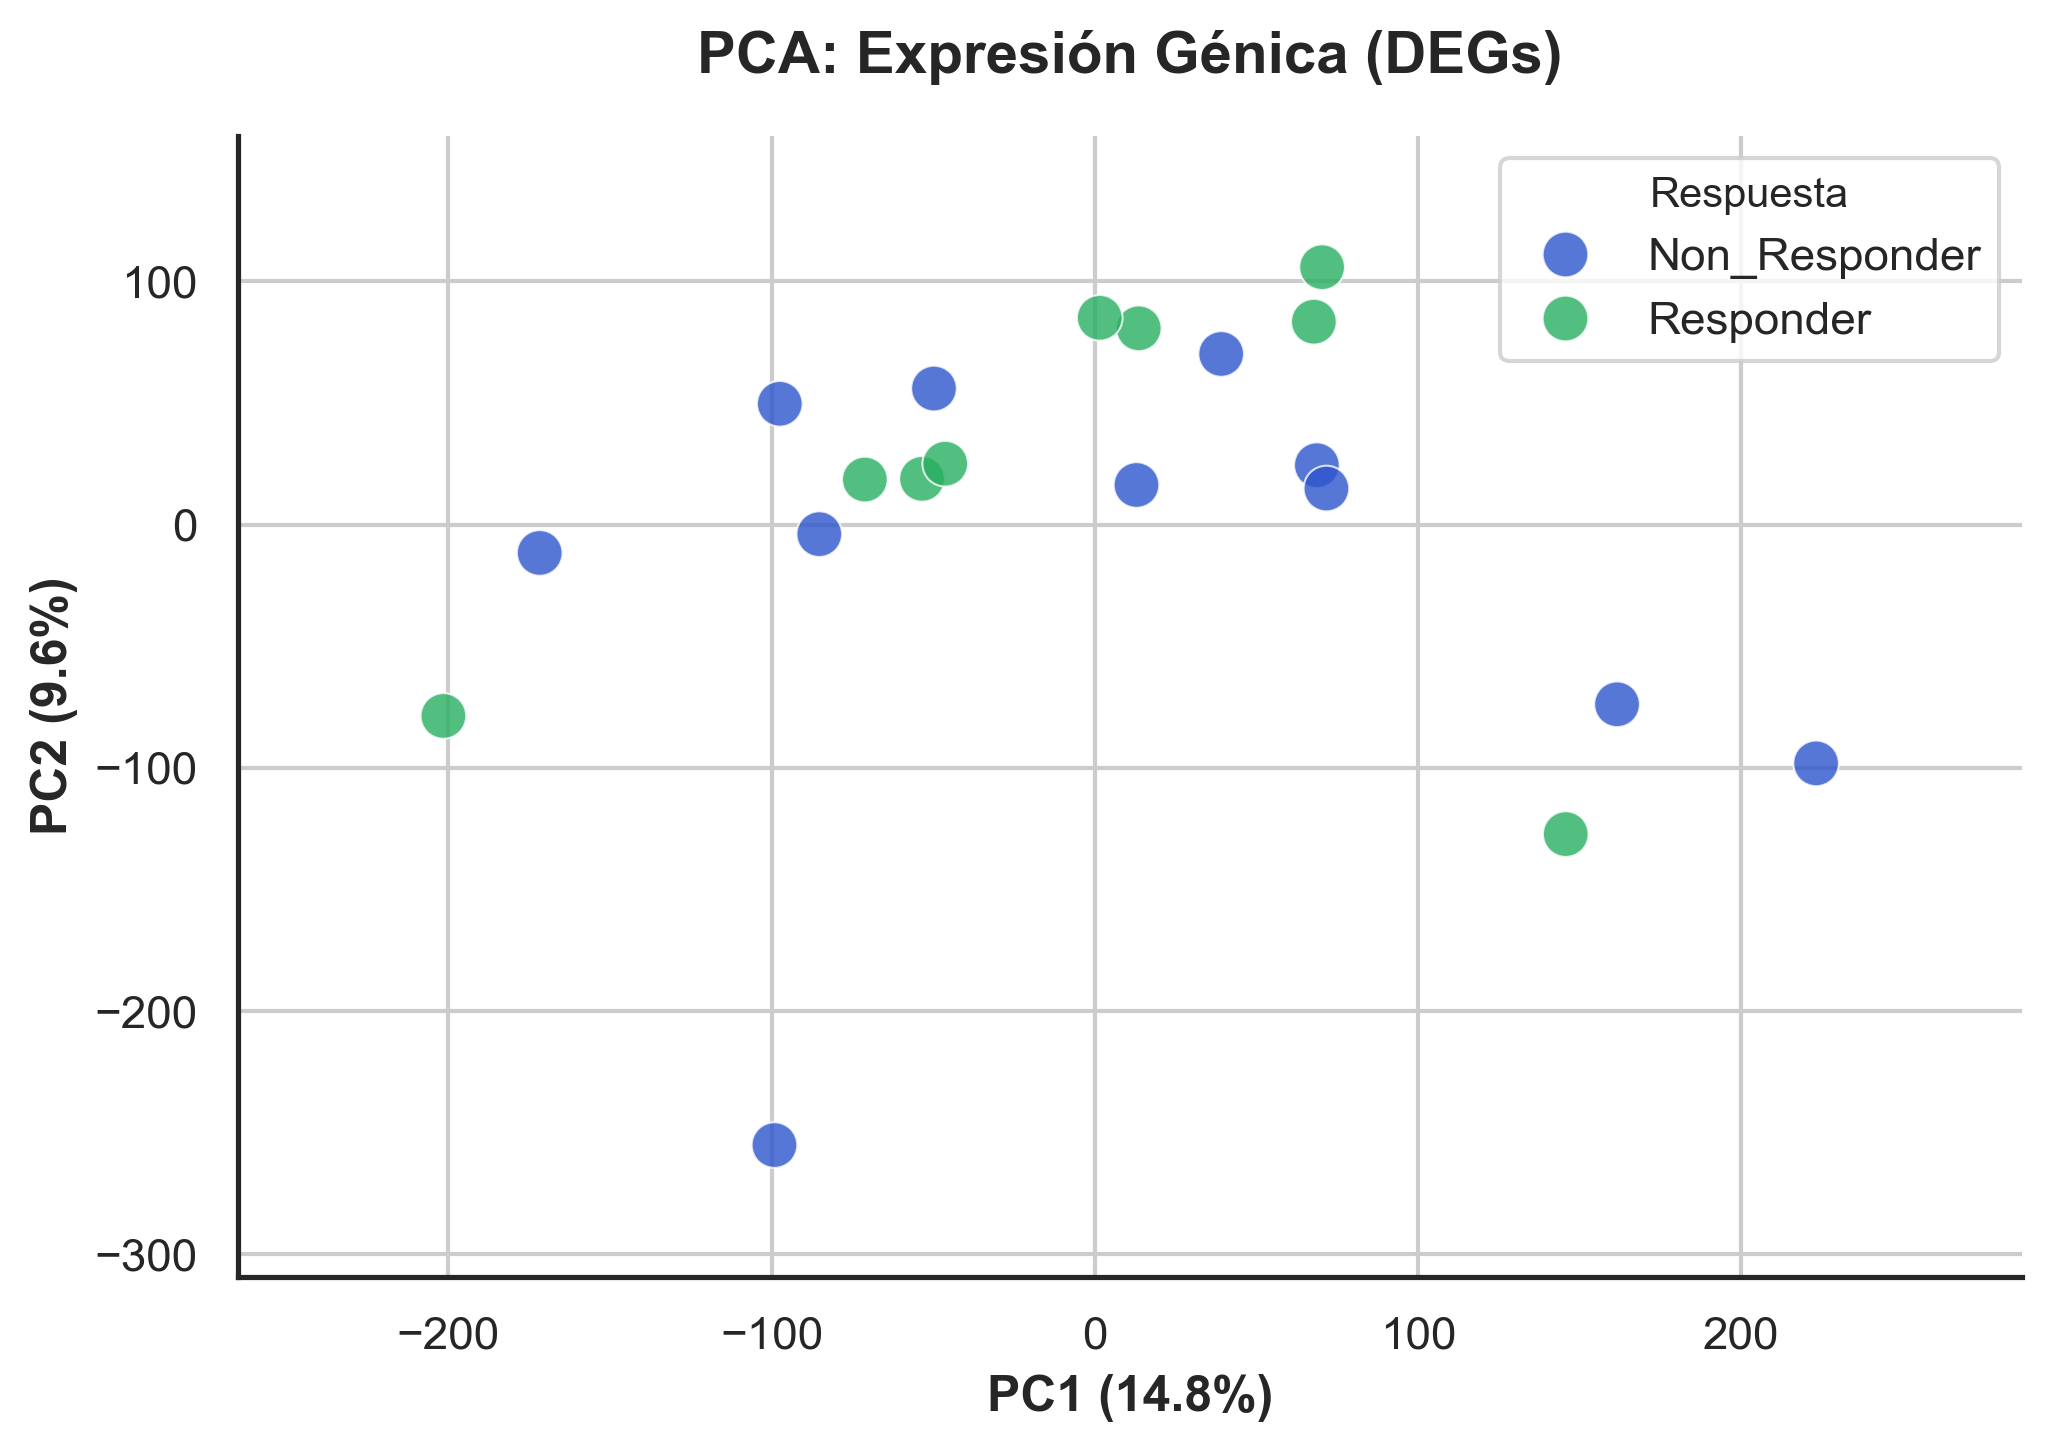

In [45]:
# Creamos la figura y el scatter plot.
sb.set_style("whitegrid", {'axes.edgecolor': '.15'})
plt.figure(figsize=(7, 5))
ax = sb.scatterplot( # Usamos sb para seaborn
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Condition', # Colorear los puntos por la columna 'Condition'
    palette={'Non_Responder': '#2D55CC', 'Responder': '#27AE60'}, # Definir colores para las condiciones
    s=120,           # Tamaño de los puntos
    alpha=0.8,       # Transparencia de los puntos
    edgecolor='w',   # Borde blanco para los puntos
    linewidth=0.5
)


# Títulos y ejes
plt.title("PCA: Expresión Génica (DEGs)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=12, fontweight='semibold')
plt.ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=12, fontweight='semibold')
plt.legend(title='Respuesta', title_fontsize='10', loc='best', frameon=True)

# Ajustes finales para el póster
plt.margins(x=0.15, y=0.15)
sb.despine()
plt.tight_layout()
#plt.savefig("PCA_Genes_RedColsi.png", dpi=300, bbox_inches='tight')
plt.show()


## 5. Visualización Volcano Plot

El Volcano Plot es una visualización estándar en el análisis de expresión diferencial que nos permite identificar rápidamente genes que son tanto biológicamente significativos (basado en el cambio de expresión, `log2FoldChange`) como estadísticamente significativos (basado en el p-valor ajustado, `padj`).

En este tipo de gráfico:
*   El eje X representa el `log2FoldChange`, indicando la magnitud y dirección del cambio de expresión.
*   El eje Y representa `-log10(padj)`, donde valores más altos indican una mayor significancia estadística.

Los genes que son más interesantes para nosotros suelen estar en las "alas" del volcán: aquellos con un alto `log2FoldChange` (positivo o negativo) y un alto `-log10(padj)` (es decir, un `padj` muy bajo), lo que los ubica en las esquinas superiores izquierda y derecha del gráfico. Estableceremos umbrales para `padj` (ej., < 0.05) y `log2FoldChange` (ej., > 1 o < -1) para resaltar los genes diferencialmente expresados.

In [46]:
# 1. Calcular el -log10(padj) PRIMERO (y manejar NaNs/ceros)
# Los p-valores ajustados pueden ser NaN para genes con conteos muy bajos o problemas de ajuste.
# Reemplazamos NaN con 1.0 (no significativo) para que -log10(1) = 0.
res_df['padj'] = res_df['padj'].fillna(1.0)

# Reemplazamos 0 en padj con un valor muy pequeño (epsilon) para evitar -inf al tomar el logaritmo.
padj_safe = res_df['padj'].replace(0, np.finfo(float).eps)
res_df['-log10(padj)'] = -np.log10(padj_safe)

# 2. Identificar genes significativos basados en umbrales
# Definimos los umbrales de significancia y fold change.
padj_threshold = 0.05
log2fc_threshold = 1.0 # Equivalente a un fold change de 2

res_df['Significant'] = "No significativo"
# Genes upregulated en 'Responder'
res_df.loc[(res_df['padj'] < padj_threshold) & (res_df['log2FoldChange'] > log2fc_threshold), 'Significant'] = "Up (Responder)"
# Genes downregulated en 'Responder'
res_df.loc[(res_df['padj'] < padj_threshold) & (res_df['log2FoldChange'] < -log2fc_threshold), 'Significant'] = "Down (Responder)"

# 3. Contar y mostrar el número de genes en cada categoría
num_up = (res_df['Significant'] == "Up (Responder)").sum()
num_down = (res_df['Significant'] == "Down (Responder)").sum()
num_total_sig = num_up + num_down
print(f"Genes upregulated (Log2FC > {log2fc_threshold}, padj < {padj_threshold}): {num_up}")
print(f"Genes downregulated (Log2FC < -{log2fc_threshold}, padj < {padj_threshold}): {num_down}")
print("Genes no significativos:", ((res_df['Significant'] != "Up (Responder)") & (res_df['Significant'] != "Down (Responder)")).sum())
print(f"Total de genes diferencialmente expresados: {num_total_sig}")

Genes upregulated (Log2FC > 1.0, padj < 0.05): 59
Genes downregulated (Log2FC < -1.0, padj < 0.05): 70
Genes no significativos: 22988
Total de genes diferencialmente expresados: 129


C:\Users\sebat\AppData\Local\Temp\ipykernel_21324\637782499.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_df['padj'] = res_df['padj'].fillna(1.0)
C:\Users\sebat\AppData\Local\Temp\ipykernel_21324\637782499.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_df['-log10(padj)'] = -np.log10(padj_safe)
C:\Users\sebat\AppData\Local\Temp\ipykernel_21324\637782499.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

Text(0, 0.5, '-log10 (p-adjusted)')

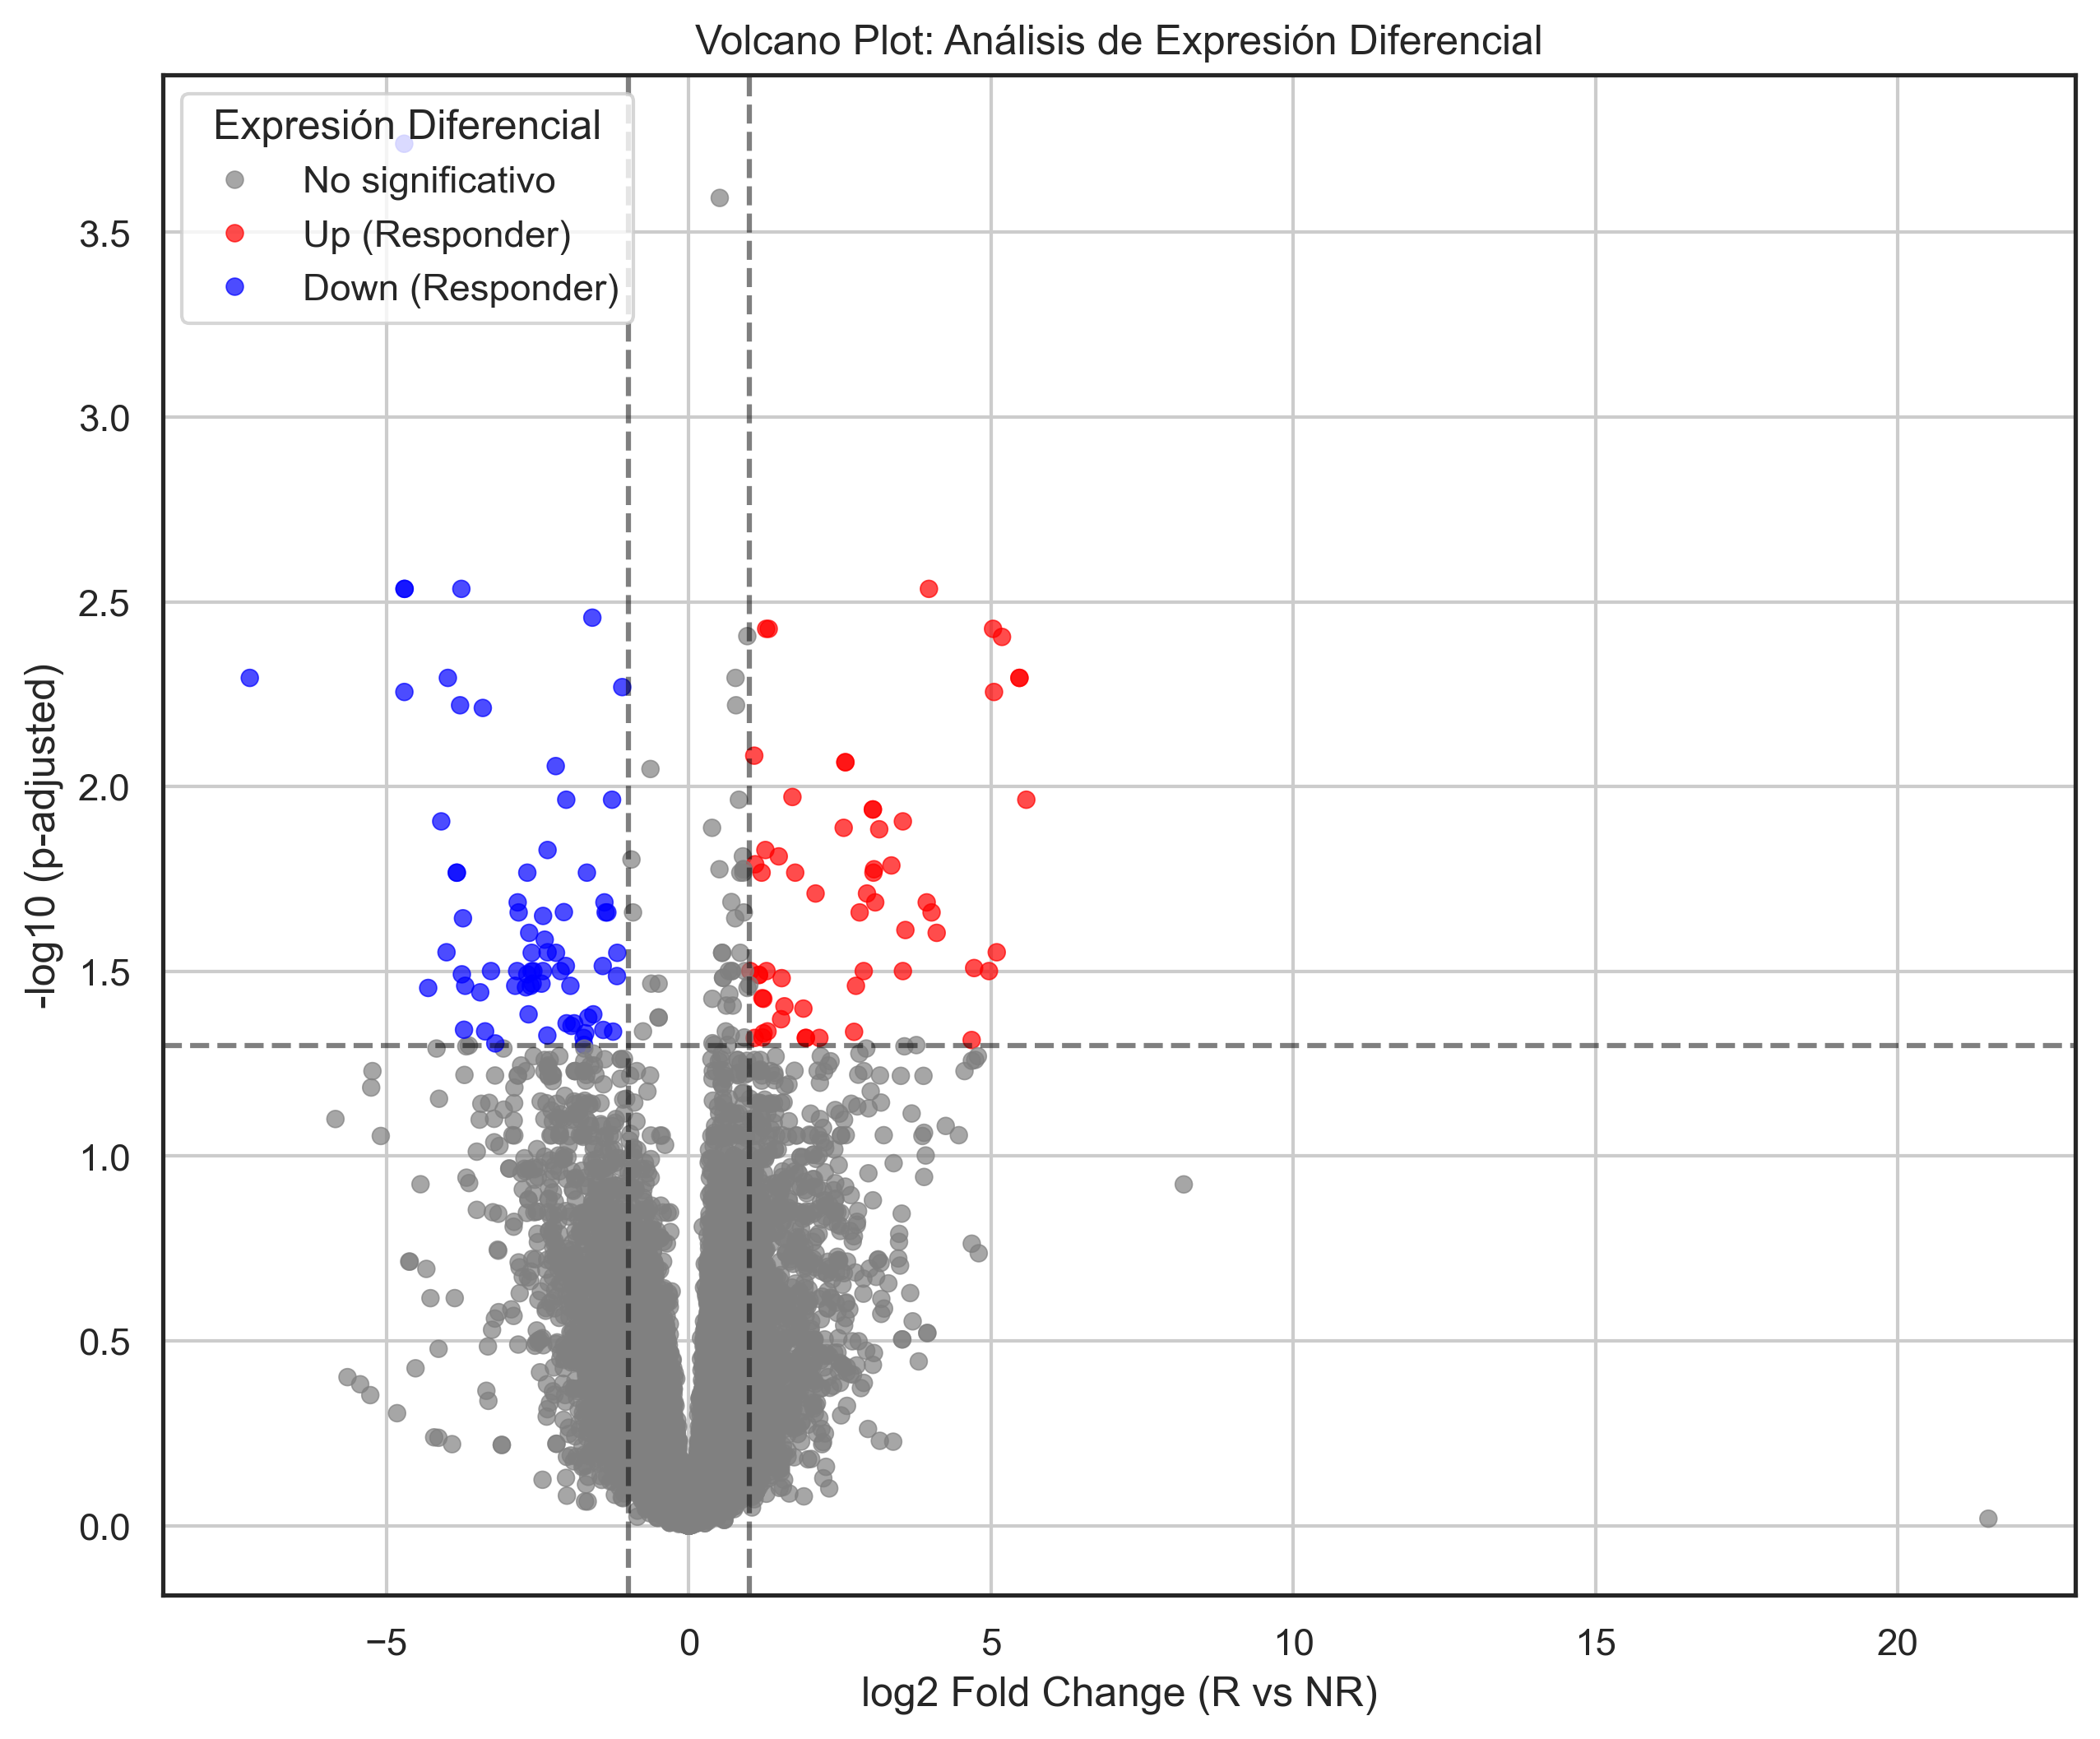

In [51]:
# Creación del Volcano Plot
plt.figure(figsize=(10, 8))

sb.scatterplot( # Usamos sb para seaborn
    data=res_df,
    x='log2FoldChange',
    y='-log10(padj)',
    hue='Significant', # Colorear por la categoría de significancia
    palette={'No significativo': 'grey', 'Up (Responder)': 'red', 'Down (Responder)': 'blue'}, # Paleta de colores
    alpha=0.7, # Transparencia
    s=25,      # Tamaño de los puntos
    edgecolor=None # Sin borde para los puntos
)

plt.axhline(y=1.3, color='black', linestyle='--', alpha=0.5) 
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5)   
plt.axvline(x=-1, color='black', linestyle='--', alpha=0.5) 

plt.legend(title='Expresión Diferencial', loc='upper left')
plt.title('Volcano Plot: Análisis de Expresión Diferencial')
plt.xlabel('log2 Fold Change (R vs NR)')
plt.ylabel('-log10 (p-adjusted)')

**Interpretación del Volcano Plot:**

*   Los puntos en la parte superior del gráfico son los genes más estadísticamente significativos (p-valores ajustados más bajos).
*   Los puntos a la derecha tienen un `log2FoldChange` positivo, indicando una mayor expresión en el grupo "Responder".
*   Los puntos a la izquierda tienen un `log2FoldChange` negativo, indicando una menor expresión en el grupo "Responder".
*   Los puntos coloreados en **rojo** y **azul** representan los genes que cumplen con ambos criterios (significancia estadística y magnitud del cambio de expresión) y son, por lo tanto, los principales candidatos para una mayor investigación.


## 6. Exportación de la Master Table de Features para Machine Learning

Después de identificar los genes diferencialmente expresados y obtener una representación de datos con varianza estabilizada (VST), el siguiente paso lógico es preparar estos datos para modelos de Machine Learning (ML). Para ML, generalmente necesitamos una matriz donde cada fila sea una "instancia" (nuestra muestra de paciente) y cada columna sea una "feature" (la expresión VST de un gen). Además, necesitamos una columna que represente la "variable objetivo" o "target label" que el modelo intentará predecir.

En este caso, nuestra variable objetivo será la condición del paciente ("Responder" o "Non_Responder"), que convertiremos a un formato numérico binario (0 o 1).

Crearemos una "Master Table" combinando la matriz `vst_counts` (nuestras features) con la columna `condition` de los metadatos (nuestro target). Finalmente, guardaremos esta tabla en formato Parquet, que es un formato columnar eficiente y optimizado para el almacenamiento y la recuperación de grandes volúmenes de datos, ideal para flujos de trabajo de Machine Learning y Big Data.

In [48]:
# Concatenamos la matriz VST (features) con la columna 'condition' de los metadatos (nuestro target).
# 'axis=1' asegura que la concatenación se haga por columnas.
# `metadata[['condition']]` se usa para asegurar que 'condition' sea un DataFrame, no una Serie,
# lo cual es más robusto para la concatenación.
master_df = pd.concat([vst_counts, metadata[['y']]], axis=1)

# Convertir el Label categórico a numérico:
# 'Non_Responder' -> 0
# 'Responder'     -> 1
# Esto es esencial para la mayoría de los algoritmos de Machine Learning.
master_df['Target_Label'] = (master_df['y'] == 'Responder').astype(int)

# Eliminamos la columna 'condition' original, ya que ahora tenemos 'Target_Label'.
master_df = master_df.drop(columns=['y'])

print(f"\nMaster Table de Features creada. Dimensiones: {master_df.shape[0]} muestras x {master_df.shape[1]} features (incluyendo Target_Label).")
print("Primeras 5 filas de la Master Table para Machine Learning:")
master_df.head()


Master Table de Features creada. Dimensiones: 20 muestras x 37759 features (incluyendo Target_Label).
Primeras 5 filas de la Master Table para Machine Learning:


,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,FAM138A,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,...,TRNH,TRNS2,TRNL2,ND5,ND6,TRNE,CYTB,TRNT,TRNP,Target_Label
EGAR00001653000,5.274582,11.998026,0.332072,-2.783465,-2.783465,0.332072,1.695661,4.639057,12.808510,0.332072,...,2.079247,-2.783465,3.341892,12.137666,10.123366,3.815606,12.071517,1.170759,5.199216,0
EGAR00001653001,4.927773,11.909099,0.212852,0.212852,-2.783465,2.883852,1.557484,3.562636,12.787475,-2.783465,...,2.487200,0.212852,1.557484,11.154245,9.362421,3.764404,10.522892,-2.783465,3.327978,0
EGAR00001653005,5.603370,12.143183,-2.783465,-2.783465,-2.783465,-2.783465,-2.783465,3.996620,12.133150,-2.783465,...,-2.783465,-2.783465,-2.783465,9.885572,7.516856,2.071699,9.212538,-2.783465,0.662914,1
EGAR00001653017,5.587174,11.614539,-2.783465,2.536137,0.253019,1.604210,0.253019,4.481784,12.052716,1.604210,...,0.253019,-2.783465,2.287099,11.617918,9.789869,3.991927,10.615518,1.082946,4.149640,1
EGAR00001653019,6.378321,11.951892,1.173069,1.173069,2.081701,2.081701,-2.783465,2.634228,11.007688,-2.783465,...,-2.783465,-2.783465,-2.783465,10.349789,8.330991,1.173069,9.399434,-2.783465,4.323891,0


In [49]:
print("¡Felicidades! Has completado un flujo de trabajo integral para el análisis de expresión diferencial y la preparación de features para Machine Learning.")

# Muestra la Master Table y su estructura

print(f"\nNúmero de muestras: {master_df.shape[0]}, Número de features (genes + Target_Label): {master_df.shape[1]}")

¡Felicidades! Has completado un flujo de trabajo integral para el análisis de expresión diferencial y la preparación de features para Machine Learning.

Número de muestras: 20, Número de features (genes + Target_Label): 37759


In [50]:
#print(f"\nGuardando Master Table en formato Parquet en: '{"ml_master_table.parquet"}'")
master_df.to_parquet("ml_master_table.parquet", engine="pyarrow")

**Revisión de la Master Table:**

La `master_df` es ahora una tabla plana donde cada fila es una muestra y cada columna (excepto `Target_Label`) es una feature numérica (expresión génica VST). La última columna, `Target_Label`, es nuestro objetivo binario.

Esta tabla es ideal para ser alimentada a algoritmos de Machine Learning para tareas como:
*   **Clasificación:** Construir un modelo para predecir si un nuevo paciente será "Responder" o "Non_Responder" basándose en su perfil de expresión génica.
*   **Selección de Características (Feature Selection):** Identificar cuáles de los genes son los más predictivos del estado de respuesta.

**Próximos Pasos con esta Tabla:**
Podrías cargar esta tabla en otro notebook o script y proceder con:
1.  **División de datos:** Entrenar y probar (Train-Test Split).
2.  **Escalado de features:** (Aunque VST ya es una buena normalización, algunos modelos pueden beneficiarse de un escalado adicional).
3.  **Selección de modelo:** (ej., Random Forest, SVM, XGBoost).
4.  **Entrenamiento y evaluación del modelo.**
5.  **Interpretación del modelo:** ¿Qué genes son los más importantes para la predicción?


## 7. Conclusión y Próximos Pasos

Aquí concluye este flujo de trabajo integral para el análisis de expresión diferencial con PyDESeq2 y la preparación de datos para Machine Learning.

En este notebook hemos cubierto:
*   La carga y el preprocesamiento de metadatos y matrices de conteos de FeatureCounts.
*   La ejecución robusta del pipeline de DESeq2 para identificar genes diferencialmente expresados.
*   La visualización de los datos a través de un PCA Plot para explorar la variabilidad entre muestras.
*   La creación de un Volcano Plot para una interpretación visual de la significancia estadística y biológica de los genes.
*   La preparación y exportación de una "Master Table" de features, lista para ser utilizada en modelos de Machine Learning, con un label objetivo claramente definido.

Este enfoque sistemático te proporciona no solo los resultados del análisis de expresión diferencial, sino también un dataset estructurado para seguir explorando tus preguntas biológicas con las potentes herramientas del Machine Learning.

### Ideas para extender el análisis:

*   **Enriquecimiento de Vías:** Realizar análisis de Gene Set Enrichment Analysis (GSEA) o Over-Representation Analysis (ORA) con los genes diferencialmente expresados para identificar vías biológicas o funciones moleculares afectadas.
*   **Clustering:** Aplicar algoritmos de clustering (ej., k-means, clustering jerárquico) a la matriz VST para identificar subgrupos de muestras o genes.
*   **Modelado de Machine Learning:** Desarrollar modelos de clasificación o regresión con la `ml_master_table.parquet` para predecir la condición del paciente basándose en el perfil de expresión.
*   **Validación:** Si se dispone de un conjunto de datos independiente, validar los genes o firmas identificadas en este análisis.

